<a href="https://colab.research.google.com/github/enkhbaaska/Metro-Ticket-Pricing-Model/blob/main/Metro_Ticket_Price_formula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Flat Fare System Scenarios

Миний бодлоор Улаанбаатрын метро тасалбар зайгаар суйрлаагүй системийг нэвтрүүлэх хэрэгтэй. Ялангуяа Монголын ахмад үеийнхэн метроны системийг сайн мэддэггүй, манай хотын автобусанд хэрэглэгддэг зайгаар суйрлаагүй тасалбар системд аль хэдийн дассан учраас энгийн тасалбар нь энгийн, ашиглахад хялбар байна. Зайгаар суйрилсан тасалбар хэрэгжүүлэхэд зорчигчдын системд хэзээ, хаана сууж, гарч байгааг тогтоох үнэтэй технологи шаардагдаж, энэ нь дэд бүтцийн зардлыг ихээхэн нэмэгдүүлэх болно.
Зайгаар суйрлаагүй тасалбарын ачаар нарийн төвөгтэй тооцоо эсвэл tap-in/tap-out горим шаардлагагүй. Түүнээс гадна, орлого багатай олон гэр бүл хотын захад амьдардаг. Зайгаар суйрилсан тасалбар тэдний хувьд аяллыг илүү үнэтэй болгож, харин тогтмол тариф нь шударга байдлыг дэмжиж, тээврийн хэрэгслийг хүн бүрд илүү хүртээмжтэй болгоно.Улаанбаатар метроны систем ердөө 19км зайтай учраас зайгаар суйрилсан тасалбар систем ямар ч ашиггүй.
DOHWA компани зайд суурилсан системийг нэвтрүүлсэн шалтгаан нь Солонгосын метроны систем зайд суурилсан учраас тэд зайд суурьлаагүй системийг сайн мэддэггүй гэж бодож байна.
Мөн оюутнууд, хүүхэд, өндөр настнууд зэрэг бүлгүүдийн тасалбарын үнийг тохируулан тээврийн хэрэгслийн системд нэвтрэх боломжийг нэмэгдүүлэх нь туйлын чухал юм. Гэхдээ Монгол улс сар болон жил тутмын тасалбар систем хийвэл ашиггүүй болно.
Гэхдээ Монгол улс тасалбарын үнэ системд цагийн ялгаатай өөрчлөлтийг хэрэгжүүлэх ёстой. Учир нь метроны үйлчлүүлэгчдийн эрэлт хэрэгцээ оргил цагт маш завгүй байх бөгөөд энэ үед тасалбарын үнэ өндөр байх ёстой. Source


Энэ судалгаанаас харахад Монгол улсын сарын дундаж орлого 2280000MNT байна. Тэгэхээр орлогын 3% нь 68400MNT буюу өдөрт 2280MNT метроны зарцуулалттай тэнцэх болно. Тиймээс нэг талын аялал 1140MNT байх ёстой.
Илүү үнэтэй appraoch нь Лондонтой адил 6% байх бөгөөд өдөрт 4560MNT, нэг талдаа 2250MNT болно. Лондонгийн метро нь хувийн бөгөөд засгийн газраар дэмжигддэггүй.
Хэрэв Монголын метро засгийн газрын дэмжлэг авахгүй бол метро компани тасалбарын төлбөрийг нэмэх эрхтэй.  [Source](https://tfl.gov.uk/corporate/about-tfl/how-we-work/how-we-are-funded?utm_source=chatgpt.com)

In [ ]:
#Importing the Libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

In [ ]:
def format_mnt(value):
    if pd.isna(value):  # Check if the value is NaN
        return "NaN"  # Or any other placeholder
    if value >= 1_000_000:
        return f"₮{int(value/1_000_000)}сая"
    elif value >= 1_000:
        return f"₮{int(value/1_000)}мянга"
    else:
        return f"₮{int(value)}"

def format_usd(value):
    if pd.isna(value):  # Check if the value is NaN
        return "NaN"  # Or any other placeholder
    if value >= 1_000_000:
        return f"${int(value/1_000_000)}сая"
    elif value >= 1_000:
        return f"${int(value/1_000)}мянга"
    else:
        return f"${int(value)}"

def round_sig(x, sig=2):
    if x == 0:
        return 0
    return round(x, sig - int(np.floor(np.log10(abs(x)))) - 1)

#Forecast of MNT to USD 2030 and 2040 according to [source](https://gov.capital/forex-forecast/usd-mnt/)



In [ ]:
from sklearn.linear_model import LinearRegression
# https://gov.capital/forex-forecast/usd-mnt/

# Forecast data points (Year → MNT per USD)
years = np.array([2026, 2030]).reshape(-1, 1)
rates = np.array([3745.51, 4406.69])

# Fit linear model
model = LinearRegression()
model.fit(years, rates)

# Extract coefficients
slope = model.coef_[0]
intercept = model.intercept_

MNTtoUSD2020 = 2020*slope+intercept
MNTtoUSD2030 = 2030*slope+intercept
MNTtoUSD2040 = 2040*slope+intercept

print(f"Forecast of MNT to USD 2030: {MNTtoUSD2030}MNT")
print(f"Forecast of MNT to USD 2040: {MNTtoUSD2040}MNT")



Forecast of MNT to USD 2030: 4406.690000000002MNT
Forecast of MNT to USD 2040: 6059.640000000014MNT


#Forecast of the average Mongolian citizen salary and affordable metro ticket price [source](https://tradingeconomics.com/mongolia/wages)

In [ ]:

# Prepare data
years = np.array([2020, 2022, 2024, 2025]).reshape(-1, 1)
salaries = np.array([1_328_000, 1_750_000, 2_672_000, 2_622_000])  # in MNT/month

# Fit the model
model = LinearRegression()
model.fit(years, salaries)

# Predict for 2030
pred_2025 = model.predict(np.array([[2025]]))[0]
pred_2030 = model.predict(np.array([[2030]]))[0]
pred_2040 = model.predict(np.array([[2040]]))[0]

afford_metroprice2025 = pred_2025/1000
afford_metroprice2030 = pred_2030/1000
afford_metroprice2040 = pred_2040/1000

print(f"Average Mongolian citizen salary in 2025: ₮{round_sig(pred_2025)}")
print(f"Average Mongolian citizen salary in 2030: ₮{round_sig(pred_2030)}")
print(f"Average Mongolian citizen salary in 2040: ₮{round_sig(pred_2040)}")

print(f"Average affordable metro ticket price 2025: ₮{round_sig(afford_metroprice2025)}")
print(f"Average affordable metro ticket price 2030: ₮{round_sig(afford_metroprice2030)}")
print(f"Average affordable metro ticket price 2040: ₮{round_sig(afford_metroprice2040)}")


Average Mongolian citizen salary in 2025: ₮2700000.0
Average Mongolian citizen salary in 2030: ₮4200000.0
Average Mongolian citizen salary in 2040: ₮7100000.0
Average affordable metro ticket price 2025: ₮2700.0
Average affordable metro ticket price 2030: ₮4200.0
Average affordable metro ticket price 2040: ₮7100.0


#Calculating the coefficient and intercept of daily demand in terms of the ticket price

In [ ]:
demand = [465821, 443339, 420990, 399102, 377675]
fare = [500, 750, 1000, 1250, 1500]

from sklearn.linear_model import LinearRegression

# Example data (replace with your own)
x = [616.1, 866.7, 1117.4, 1368.2, 1618.9]
y = [465821, 443339, 420990, 399102, 377675]

# Convert x to a 2D array (required by sklearn)
X = np.array(x).reshape(-1, 1)
Y = np.array(y)

# Create and fit the model
model = LinearRegression()
model.fit(X, Y)

# Get the coefficients
demand_coef = model.coef_[0]     # Slope
deman_intercept = model.intercept_   # Intercept



# Scenario of Children fare half the price of Adult

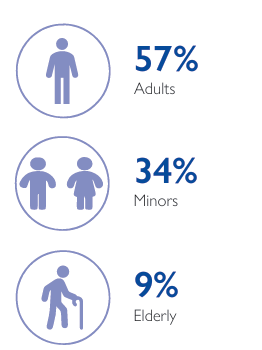

[Source Page6](https://dtm.iom.int/sites/g/files/tmzbdl1461/files/reports/Ulaanbaatar_Phase2_ENG.pdf)

In [ ]:
start_fare = 1000
increment = 250
num_scenarios = 8

# Prepare data
data = []
for i in range(num_scenarios):
    scenario = i + 1
    adult_fare = start_fare + i * increment
    children_fare = round_sig(adult_fare * 0.5)
    daily_demand = adult_fare * demand_coef + deman_intercept
    revenue = (adult_fare*0.63 + children_fare*0.37) * daily_demand
    data.append({'Scenario': scenario, 'Adult Fare (MNT)': adult_fare, 'Children Fare (MNT)': children_fare, 'Daily Demand':daily_demand, 'Revenue (MNT)': revenue, 'Revenue': format_mnt(revenue)})

# Create DataFrame
df = pd.DataFrame(data)
df

,Scenario,Adult Fare (MNT),Children Fare (MNT),Daily Demand,Revenue (MNT),Revenue
0,1,1000,500.0,431717.382254,3.518497e+08,₮351сая
1,2,1250,620.0,409726.955185,4.166513e+08,₮416сая
2,3,1500,750.0,387736.528116,4.740079e+08,₮474сая
3,4,1750,880.0,365746.101047,5.223220e+08,₮522сая
4,5,2000,1000.0,343755.673977,5.603217e+08,₮560сая
5,6,2250,1100.0,321765.246908,5.870607e+08,₮587сая
6,7,2500,1200.0,299774.819839,6.052454e+08,₮605сая
7,8,2750,1400.0,277784.392770,6.251538e+08,₮625сая


In [ ]:
start_fare = 1000
increment = 250
num_scenarios = 8

# Prepare data
data = []
for i in range(num_scenarios):
    scenario = i + 1
    adult_fare = start_fare + i * increment
    children_fare = round_sig(adult_fare * 0.75)
    daily_demand = adult_fare * demand_coef + deman_intercept
    revenue = (adult_fare*0.63 + children_fare*0.37) * daily_demand
    data.append({'Scenario': scenario, 'Adult Fare (MNT)': adult_fare, 'Children Fare (MNT)': children_fare, 'Daily Demand':daily_demand, 'Revenue (MNT)': revenue, 'Revenue': format_mnt(revenue)})

# Create DataFrame
df = pd.DataFrame(data)
df

,Scenario,Adult Fare (MNT),Children Fare (MNT),Daily Demand,Revenue (MNT),Revenue
0,1,1000,750.0,431717.382254,3.917835e+08,₮391сая
1,2,1250,940.0,409726.955185,4.651630e+08,₮465сая
2,3,1500,1100.0,387736.528116,5.242198e+08,₮524сая
3,4,1750,1300.0,365746.101047,5.791590e+08,₮579сая
4,5,2000,1500.0,343755.673977,6.239165e+08,₮623сая
5,6,2250,1700.0,321765.246908,6.584926e+08,₮658сая
6,7,2500,1900.0,299774.819839,6.828870e+08,₮682сая
7,8,2750,2100.0,277784.392770,6.970999e+08,₮697сая


Оргил цагт аялах тоо нь өдрийн нийт эрэлт хэрэгцээний 54%-ийг эзэлж байна [Peak Hour percent](https://www.ft.com/content/2c85492b-8a16-40b7-b2f0-a9fa5622e147).
Monday to Friday (excluding public holidays):

Morning peak: 06:30 – 09:30

Evening peak: 16:00 – 19:00

Off-peak:
All other times, including weekends and public holidays.

> Add blockquote



In [ ]:
start_fare = 500
increment = 250
num_scenarios = 10
peakhour_percent = 0.54
peakhour_increase = 1.2

# Prepare data
data = []
for i in range(num_scenarios):
    scenario = i + 1
    adult_fare = start_fare + i * increment
    adult_fare_peak = round_sig(adult_fare * peakhour_increase)
    children_fare = round_sig(adult_fare * 0.5)
    children_fare_peak = round_sig(children_fare * 1.2)
    daily_demand = adult_fare * demand_coef + deman_intercept
    revenue = ((adult_fare*(1-peakhour_percent)+adult_fare_peak*peakhour_percent)*0.63 + (children_fare*(1-peakhour_percent)+children_fare_peak*peakhour_percent)*0.37) * daily_demand
    data.append({'Scenario': scenario, 'Adult Fare (MNT)': adult_fare, 'Adult Fare Peak(MNT)': adult_fare_peak, 'Children Fare (Half Price) (MNT)': children_fare, 'Children Fare peak (MNT)': children_fare_peak, 'Daily Demand':daily_demand, 'Revenue (MNT)': revenue, 'Daily Weekday Revenue': format_mnt(revenue)})

# Create DataFrame
df = pd.DataFrame(data)
df

,Scenario,Adult Fare (MNT),Adult Fare Peak(MNT),Children Fare (Half Price) (MNT),Children Fare peak (MNT),Daily Demand,Revenue (MNT),Daily Weekday Revenue
0,1,500,600.0,250.0,300.0,475698.236393,2.147825e+08,₮214сая
1,2,750,900.0,380.0,460.0,453707.809323,3.085730e+08,₮308сая
2,3,1000,1200.0,500.0,600.0,431717.382254,3.898494e+08,₮389сая
3,4,1250,1500.0,620.0,740.0,409726.955185,4.613222e+08,₮461сая
4,5,1500,1800.0,750.0,900.0,387736.528116,5.252008e+08,₮525сая
5,6,1750,2100.0,880.0,1100.0,365746.101047,5.819481e+08,₮581сая
6,7,2000,2400.0,1000.0,1200.0,343755.673977,6.208365e+08,₮620сая
7,8,2250,2700.0,1100.0,1300.0,321765.246908,6.491775e+08,₮649сая
8,9,2500,3000.0,1200.0,1400.0,299774.819839,6.682161e+08,₮668сая
9,10,2750,3300.0,1400.0,1700.0,277784.392770,6.937804e+08,₮693сая


In [ ]:
start_fare = 500
increment = 250
num_scenarios = 10
peakhour_percent = 0.54
peakhour_increase = 1.2

# Prepare data
data = []
for i in range(num_scenarios):
    scenario = i + 1
    adult_fare = start_fare + i * increment
    adult_fare_peak = round_sig(adult_fare * peakhour_increase)
    children_fare = round_sig(adult_fare * 0.8)
    children_fare_peak = round_sig(children_fare * 1.2)
    daily_demand = adult_fare * demand_coef + deman_intercept
    revenue = ((adult_fare*(1-peakhour_percent)+adult_fare_peak*peakhour_percent)*0.63 + (children_fare*(1-peakhour_percent)+children_fare_peak*peakhour_percent)*0.37) * daily_demand
    data.append({'Scenario': scenario, 'Adult Fare (MNT)': adult_fare, 'Adult Fare Peak(MNT)': adult_fare_peak, 'Children Fare (20% off) (MNT)': children_fare, 'Children Fare peak (MNT)': children_fare_peak, 'Daily Demand':daily_demand, 'Revenue (MNT)': revenue, 'Daily Weekday Revenue': format_mnt(revenue)})

# Create DataFrame
df = pd.DataFrame(data)
df

,Scenario,Adult Fare (MNT),Adult Fare Peak(MNT),Children Fare (20% off) (MNT),Children Fare peak (MNT),Daily Demand,Revenue (MNT),Daily Weekday Revenue
0,1,500,600.0,400.0,480.0,475698.236393,2.440351e+08,₮244сая
1,2,750,900.0,600.0,720.0,453707.809323,3.491309e+08,₮349сая
2,3,1000,1200.0,800.0,960.0,431717.382254,4.429455e+08,₮442сая
3,4,1250,1500.0,1000.0,1200.0,409726.955185,5.254789e+08,₮525сая
4,5,1500,1800.0,1200.0,1400.0,387736.528116,5.936324e+08,₮593сая
5,6,1750,2100.0,1400.0,1700.0,365746.101047,6.581638e+08,₮658сая
6,7,2000,2400.0,1600.0,1900.0,343755.673977,7.040185e+08,₮704сая
7,8,2250,2700.0,1800.0,2200.0,321765.246908,7.453724e+08,₮745сая
8,9,2500,3000.0,2000.0,2400.0,299774.819839,7.689284e+08,₮768сая
9,10,2750,3300.0,2200.0,2600.0,277784.392770,7.815547e+08,₮781сая


#2040 Daily demand Coefficient

In [ ]:
from sklearn.linear_model import LinearRegression

# Example data (replace with your own)
x2 = [623.3, 873.8, 1124.5, 1375.2, 1626.1]
y2 = [532540, 507643, 482799, 457880, 432791]

# Convert x to a 2D array (required by sklearn)
X2 = np.array(x2).reshape(-1, 1)
Y2 = np.array(y2)

# Create and fit the model
model = LinearRegression()
model.fit(X2, Y2)

# Get the coefficients
demand_coef2 = model.coef_[0]     # Slope
deman_intercept2 = model.intercept_   # Intercept



#2040 Demand and Fare System

In [ ]:
start_fare = 1000
increment = 250
num_scenarios = 18
peakhour_percent = 0.54
peakhour_increase = 1.2
child_discount = 0.6

# Prepare data
data = []
for i in range(num_scenarios):
    scenario = i + 1
    adult_fare = start_fare + i * increment
    adult_fare_peak = round_sig(adult_fare * peakhour_increase)
    children_fare = round_sig(adult_fare * child_discount)
    children_fare_peak = round_sig(children_fare * peakhour_increase)
    daily_demand = adult_fare * demand_coef2 + deman_intercept2
    average_fare = (adult_fare*(1-peakhour_percent)+adult_fare_peak*peakhour_percent)*0.63 + (children_fare*(1-peakhour_percent)+children_fare_peak*peakhour_percent)*0.37
    revenue = ((adult_fare*(1-peakhour_percent)+adult_fare_peak*peakhour_percent)*0.63 + (children_fare*(1-peakhour_percent)+children_fare_peak*peakhour_percent)*0.37) * daily_demand
    weekend_revenue = (adult_fare*0.63+children_fare*0.37)*daily_demand
    yearly_revenue = (revenue*260+weekend_revenue*105)/MNTtoUSD2040
    data.append({'Scenario': scenario, 'Adult Fare (MNT)': adult_fare, 'Adult Fare Peak(MNT)': adult_fare_peak, 'Children Fare (40% off) (MNT)': children_fare, 'Children Fare peak (MNT)': children_fare_peak, 'Daily Demand':daily_demand, 'Average Fare':average_fare, 'Revenue (MNT)': revenue, 'Daily Weekday Revenue': format_mnt(revenue), 'Yearly Revenue (USD)': format_usd(yearly_revenue)})


# Create DataFrame
df = pd.DataFrame(data)
df.to_excel('output.xlsx', index=False)
df

,Scenario,Adult Fare (MNT),Adult Fare Peak(MNT),Children Fare (40% off) (MNT),Children Fare peak (MNT),Daily Demand,Average Fare,Revenue (MNT),Daily Weekday Revenue,Yearly Revenue (USD)
0,1,1000,1200.0,600.0,720.0,495117.096190,944.016,4.673985e+08,₮467сая,$27сая
1,2,1250,1500.0,750.0,900.0,470260.585935,1180.020,5.549169e+08,₮554сая,$32сая
2,3,1500,1800.0,900.0,1100.0,445404.075681,1420.020,6.324827e+08,₮632сая,$37сая
3,4,1750,2100.0,1000.0,1200.0,420547.565426,1631.530,6.861360e+08,₮686сая,$40сая
4,5,2000,2400.0,1200.0,1400.0,395691.055172,1880.040,7.439150e+08,₮743сая,$43сая
5,6,2250,2700.0,1400.0,1700.0,370834.544917,2148.530,7.967491e+08,₮796сая,$46сая
6,7,2500,3000.0,1500.0,1800.0,345978.034663,2360.040,8.165220e+08,₮816сая,$47сая
7,8,2750,3300.0,1600.0,1900.0,321121.524408,2571.550,8.257801e+08,₮825сая,$48сая
8,9,3000,3600.0,1800.0,2200.0,296265.014154,2840.040,8.414045e+08,₮841сая,$49сая
9,10,3250,3900.0,2000.0,2400.0,271408.503899,3088.550,8.382587e+08,₮838сая,$49сая


#2030 Demand and Fare System

In [ ]:
start_fare = 1000
increment = 250
num_scenarios = 18
peakhour_percent = 0.54
peakhour_increase = 1.2
child_discount = 0.6

# Prepare data
data = []
for i in range(num_scenarios):
    scenario = i + 1
    adult_fare = start_fare + i * increment
    adult_fare_peak = round_sig(adult_fare * peakhour_increase)
    children_fare = round_sig(adult_fare * child_discount)
    children_fare_peak = round_sig(children_fare * peakhour_increase)
    daily_demand = adult_fare * demand_coef + deman_intercept
    average_fare = (adult_fare*(1-peakhour_percent)+adult_fare_peak*peakhour_percent)*0.63 + (children_fare*(1-peakhour_percent)+children_fare_peak*peakhour_percent)*0.37
    revenue = ((adult_fare*(1-peakhour_percent)+adult_fare_peak*peakhour_percent)*0.63 + (children_fare*(1-peakhour_percent)+children_fare_peak*peakhour_percent)*0.37) * daily_demand
    weekend_revenue = (adult_fare*0.63+children_fare*0.37)*daily_demand
    yearly_revenue = (revenue*260+weekend_revenue*105)/MNTtoUSD2030
    data.append({'Scenario': scenario, 'Adult Fare (MNT)': adult_fare, 'Adult Fare Peak(MNT)': adult_fare_peak, 'Children Fare (40% off) (MNT)': children_fare, 'Children Fare peak (MNT)': children_fare_peak, 'Daily Demand':daily_demand, 'Average Fare':average_fare, 'Revenue (MNT)': revenue, 'Daily Weekday Revenue': format_mnt(revenue), 'Yearly Revenue (USD)': format_usd(yearly_revenue)})


# Create DataFrame
df = pd.DataFrame(data)
df.to_excel('output2.xlsx', index=False)
df

,Scenario,Adult Fare (MNT),Adult Fare Peak(MNT),Children Fare (40% off) (MNT),Children Fare peak (MNT),Daily Demand,Average Fare,Revenue (MNT),Daily Weekday Revenue,Yearly Revenue (USD)
0,1,1000,1200.0,600.0,720.0,431717.382254,944.016,4.075481e+08,₮407сая,$32сая
1,2,1250,1500.0,750.0,900.0,409726.955185,1180.020,4.834860e+08,₮483сая,$38сая
2,3,1500,1800.0,900.0,1100.0,387736.528116,1420.020,5.505936e+08,₮550сая,$44сая
3,4,1750,2100.0,1000.0,1200.0,365746.101047,1631.530,5.967257e+08,₮596сая,$48сая
4,5,2000,2400.0,1200.0,1400.0,343755.673977,1880.040,6.462744e+08,₮646сая,$52сая
5,6,2250,2700.0,1400.0,1700.0,321765.246908,2148.530,6.913223e+08,₮691сая,$55сая
6,7,2500,3000.0,1500.0,1800.0,299774.819839,2360.040,7.074806e+08,₮707сая,$56сая
7,8,2750,3300.0,1600.0,1900.0,277784.392770,2571.550,7.143365e+08,₮714сая,$57сая
8,9,3000,3600.0,1800.0,2200.0,255793.965700,2840.040,7.264651e+08,₮726сая,$58сая
9,10,3250,3900.0,2000.0,2400.0,233803.538631,3088.550,7.221139e+08,₮722сая,$58сая


#Distance based fare

In [ ]:
# start_fare = 1000
# increment = 250
# num_scenarios = 18
# outside_5km = 1.2

# # Prepare data
# data = []
# for i in range(num_scenarios):
#     scenario = i + 1
#     adult_fare = start_fare + i * increment
#     adult_fare_outside5km = adult_fare *
#     daily_demand = adult_fare * demand_coef + deman_intercept
#     revenue = (adult_fare* * daily_demand
#     data.append({'Scenario': scenario, 'Adult Fare (MNT)': adult_fare,

# df = pd.DataFrame(data)
# df


120.6896551724138